In [5]:
import sys
import os

# Adds the project root directory to the Python search path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_asset
from scripts.preprocessing import preprocess
from scripts.risk_metrics import *
from src.stationarity import adf_test

In [6]:
tsla = preprocess(load_asset("../data/raw/TSLA.csv"))
spy = preprocess(load_asset("../data/raw/SPY.csv"))
bnd = preprocess(load_asset("../data/raw/BND.csv"))

In [7]:
tsla.describe()
spy.describe()
bnd.describe()

,Close,High,Low,Open,Volume
count,2891.000000,2891.000000,2891.000000,2891.000000,2.891000e+03
mean,66.288234,66.385026,66.189623,66.290513,4.662793e+06
std,4.702851,4.709101,4.694986,4.702552,3.034192e+06
min,58.531723,58.604107,58.495542,58.560671,0.000000e+00
25%,62.269064,62.328305,62.198238,62.265786,2.234250e+06
50%,65.517677,65.639425,65.387203,65.494337,4.282400e+06
75%,70.507683,70.642073,70.331718,70.492110,6.250700e+06
max,74.581306,74.672943,74.547966,74.639609,3.396300e+07


In [8]:
tsla.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

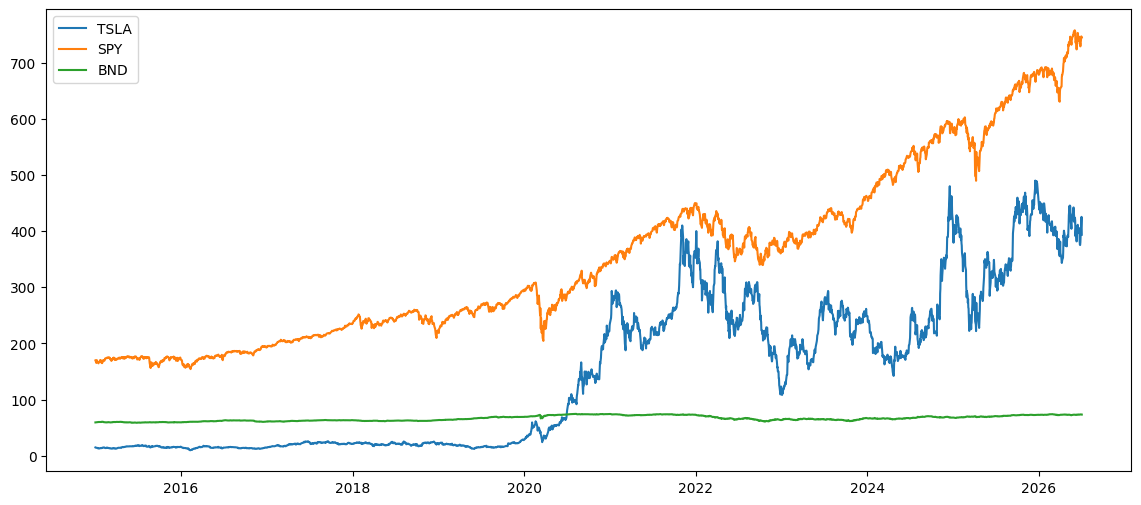

In [9]:
plt.figure(figsize=(14,6))

plt.plot(tsla["Close"], label="TSLA")

plt.plot(spy["Close"], label="SPY")

plt.plot(bnd["Close"], label="BND")

plt.legend()

plt.show()

<Axes: xlabel='Date'>

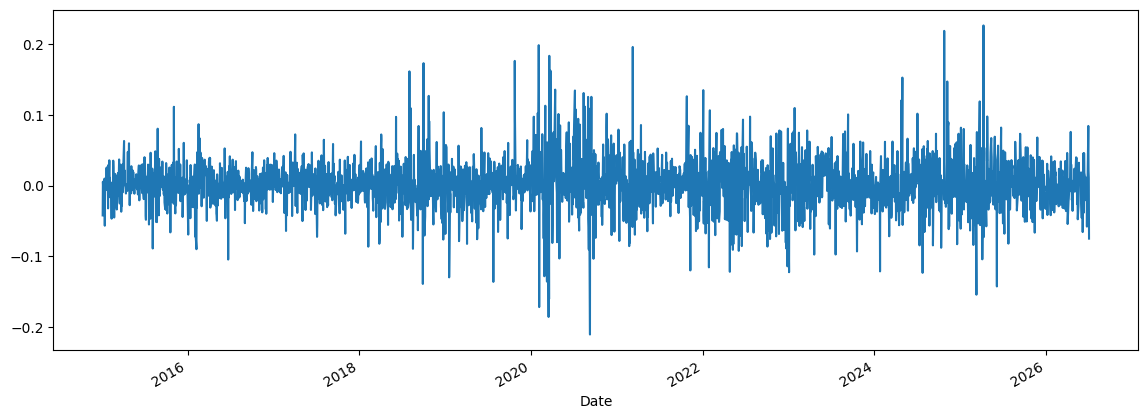

In [10]:
returns = tsla["Close"].pct_change()

returns.plot(figsize=(14,5))

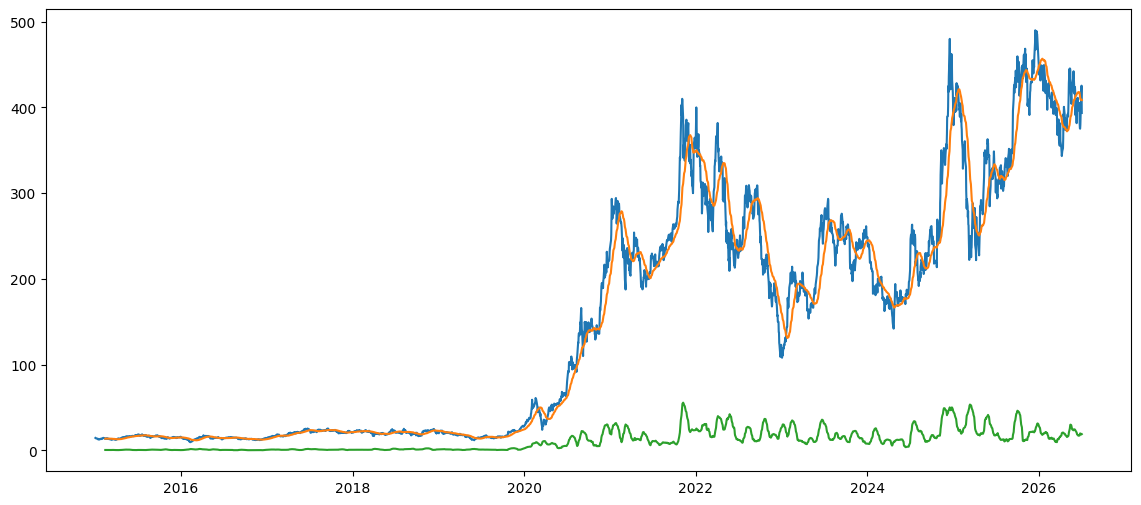

In [11]:
rolling_mean = tsla["Close"].rolling(30).mean()

rolling_std = tsla["Close"].rolling(30).std()

plt.figure(figsize=(14,6))

plt.plot(tsla["Close"])

plt.plot(rolling_mean)

plt.plot(rolling_std)

plt.show()

<Axes: xlabel='Close'>

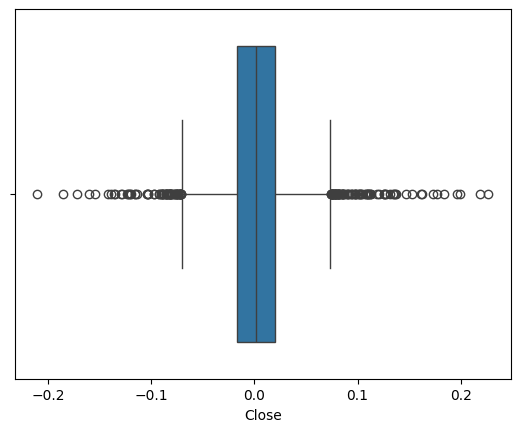

In [12]:
sns.boxplot(x=returns)

In [13]:
adf_test(tsla["Close"])
adf_test(returns.dropna())

{'ADF Statistic': np.float64(-53.9909760520347),
 'p-value': 0.0,
 'Critical Values': {'1%': np.float64(-3.432615531267606),
  '5%': np.float64(-2.8625409589326205),
  '10%': np.float64(-2.5673028391515254)}}

In [14]:
returns = returns.dropna()

print("Sharpe Ratio")

print(sharpe_ratio(returns))

print("Value at Risk")

print(value_at_risk(returns))

Sharpe Ratio
0.7868818702902463
Value at Risk
-0.05199366109853648


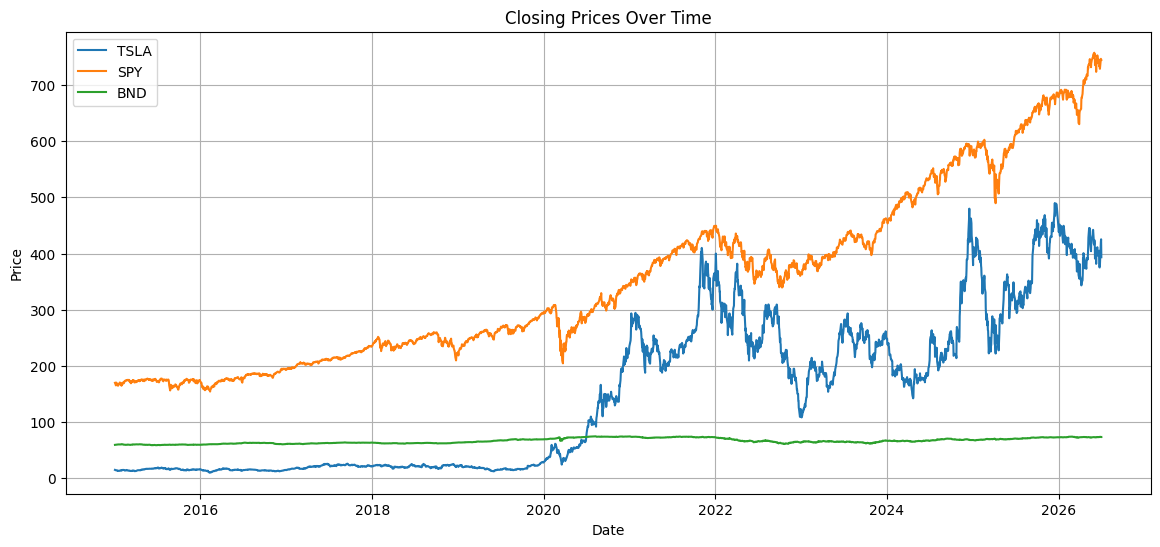

In [15]:
plt.figure(figsize=(14,6))

plt.plot(tsla.index, tsla["Close"], label="TSLA")
plt.plot(spy.index, spy["Close"], label="SPY")
plt.plot(bnd.index, bnd["Close"], label="BND")

plt.title("Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

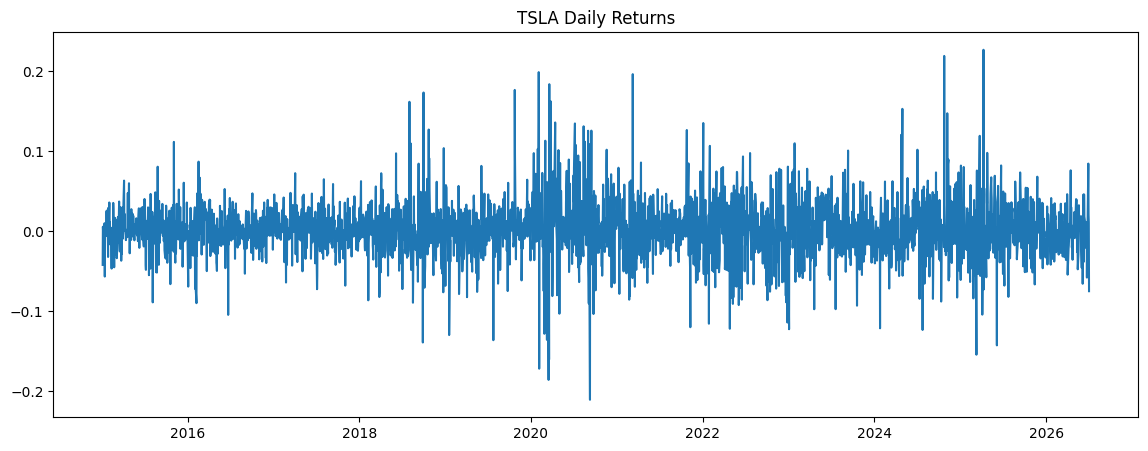

In [16]:
returns = tsla["Close"].pct_change()

plt.figure(figsize=(14,5))

plt.plot(returns)

plt.title("TSLA Daily Returns")

plt.show()

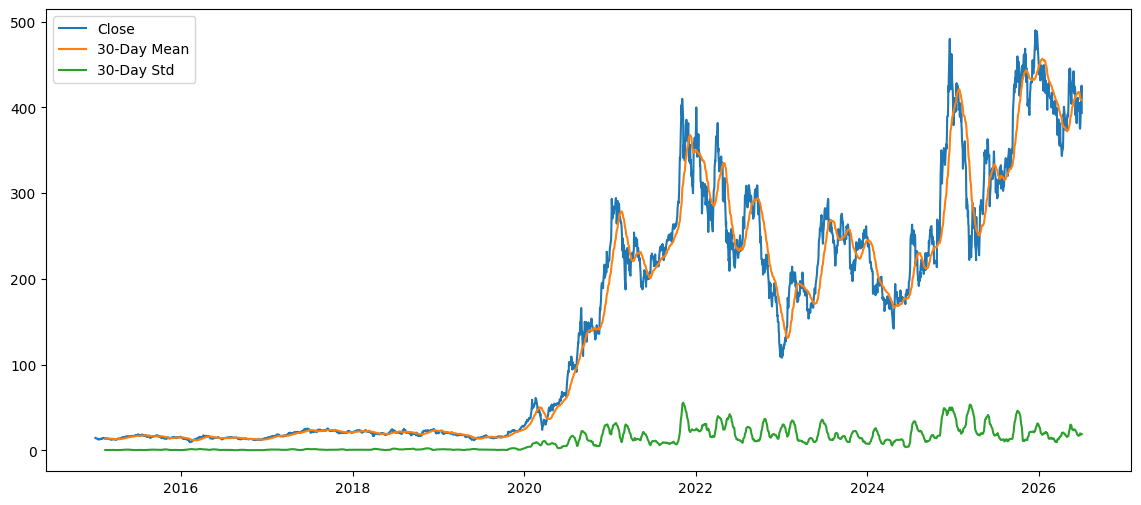

In [17]:
rolling_mean = tsla["Close"].rolling(30).mean()
rolling_std = tsla["Close"].rolling(30).std()

plt.figure(figsize=(14,6))

plt.plot(tsla["Close"], label="Close")
plt.plot(rolling_mean, label="30-Day Mean")
plt.plot(rolling_std, label="30-Day Std")

plt.legend()

plt.show()

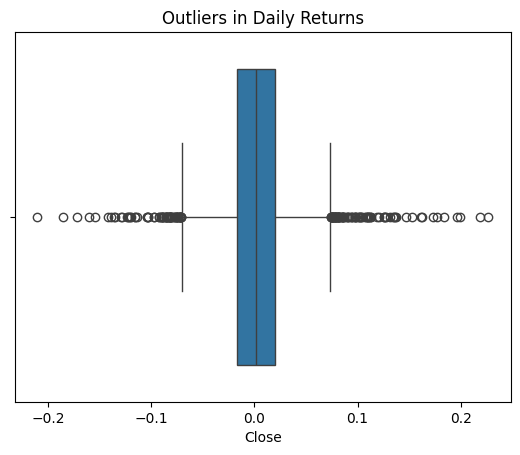

In [18]:


sns.boxplot(x=returns.dropna())

plt.title("Outliers in Daily Returns")

plt.show()

In [19]:
returns = tsla["Close"].pct_change().dropna()

adf_test(returns)

{'ADF Statistic': np.float64(-53.9909760520347),
 'p-value': 0.0,
 'Critical Values': {'1%': np.float64(-3.432615531267606),
  '5%': np.float64(-2.8625409589326205),
  '10%': np.float64(-2.5673028391515254)}}